# Public Transport Delay Prediction

This notebook explores the dataset and prepares a clean machine learning workflow. This project explores two related prediction tasks using the same public transport dataset.

## Goal
The **main task** is a classification problem: predicting whether a trip will be delayed (`delayed`). This is more practical for operational decision-making because transport systems often need an early warning about the likelihood of delay rather than an exact minute estimate.

The **secondary task** is a regression problem: predicting the exact arrival delay in minutes (`actual_arrival_delay_min`). This was included to test whether minute-level delay prediction was feasible with the available schedule, weather, traffic, and event features.


## Why these models were chosen


For regression, the project compares **Linear Regression**, **Random Forest Regressor**, **Gradient Boosting Regressor**, and **XGBoost Regressor** against a dummy baseline. Linear Regression provides a simple interpretable baseline, while tree-based methods are better suited to nonlinear tabular patterns.

For classification, the project compares **Logistic Regression**, **Random Forest Classifier**, **Gradient Boosting Classifier**, and **XGBoost Classifier** against a dummy baseline. Logistic Regression provides a simple baseline, while tree-based ensemble models can capture interactions between peak-hour, weather, traffic, and event-related features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("public_transport_delays.csv")
print(df.shape)
df.head()

(2000, 24)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## 1. Inspecting columns and missing values

In [2]:
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

trip_id                        object
date                           object
time                           object
transport_type                 object
route_id                       object
origin_station                 object
destination_station            object
scheduled_departure            object
scheduled_arrival              object
actual_departure_delay_min      int64
actual_arrival_delay_min        int64
weather_condition              object
temperature_C                 float64
humidity_percent                int64
wind_speed_kmh                  int64
precipitation_mm              float64
event_type                     object
event_attendance_est            int64
traffic_congestion_index        int64
holiday                         int64
peak_hour                       int64
weekday                         int64
season                         object
delayed                         int64
dtype: object

Missing values:
event_type                    1173
trip_id               

## 2. Basic observations from inspection

- `event_type` has many missing values, which likely means **no event**
- `delayed` is a classification label
- `actual_arrival_delay_min` is a regression target
- `actual_departure_delay_min` is not safe to use for a clean pre-trip prediction model


## Why some columns were removed to avoid data leakage

To keep the prediction task realistic, columns that directly reveal the outcome were removed from the model inputs.

For the **regression task**, the model predicts `actual_arrival_delay_min`, so the columns `actual_departure_delay_min` and `delayed` were excluded. These variables contain direct or near-direct information about the target and would make the task unrealistically easy.

For the **classification task**, the model predicts `delayed`, so the columns `actual_departure_delay_min` and `actual_arrival_delay_min` were excluded. Those values are only known after the trip has already progressed or finished, so they should not be available at prediction time.

Removing leakage columns ensures that the models rely only on information that would be available before or around departure, such as route, transport mode, scheduled timing, weather, traffic congestion, holidays, and city events.

In [7]:
# Quick check of columns that should not be used directly as model inputs
leakage_columns = [
    "actual_departure_delay_min",
    "actual_arrival_delay_min",
    "delayed"
]

print("Columns treated as leakage / target-related columns:")
for col in leakage_columns:
    if col in df.columns:
        print("-", col)

Columns treated as leakage / target-related columns:
- actual_departure_delay_min
- actual_arrival_delay_min
- delayed


## Feature engineering

Raw transport records often do not directly provide the best features for machine learning. To improve the signal available to the models, additional features are being created from dates, times, weather conditions, traffic, and event information.

The goal of feature engineering here is to transform raw operational fields into more meaningful predictors such as:

- calendar features like month, day, and weekend indicator
- time-based features like departure hour and commute peak flags
- event-based signals such as whether an event is happening
- weather severity flags such as rain, snow, storm, fog, and extreme temperature
- traffic intensity indicators

These engineered features help the models capture patterns that may not be obvious from the raw columns alone.

In [8]:
import pandas as pd
import numpy as np

df_fe = df.copy()

# Fill missing event values
df_fe["event_type"] = df_fe["event_type"].fillna("NoEvent").replace("", "NoEvent")

# Date features
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")
df_fe["month"] = df_fe["date"].dt.month
df_fe["day"] = df_fe["date"].dt.day
df_fe["day_of_year"] = df_fe["date"].dt.dayofyear
df_fe["is_weekend"] = (df_fe["date"].dt.dayofweek >= 5).astype(int)

# Time parsing
dep_split = df_fe["scheduled_departure"].astype(str).str.split(":", expand=True)
arr_split = df_fe["scheduled_arrival"].astype(str).str.split(":", expand=True)

df_fe["scheduled_departure_hour"] = pd.to_numeric(dep_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_departure_minute"] = pd.to_numeric(dep_split[1], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_hour"] = pd.to_numeric(arr_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_minute"] = pd.to_numeric(arr_split[1], errors="coerce").fillna(0).astype(int)

df_fe["scheduled_departure_minute_of_day"] = (
    df_fe["scheduled_departure_hour"] * 60 + df_fe["scheduled_departure_minute"]
)
df_fe["scheduled_arrival_minute_of_day"] = (
    df_fe["scheduled_arrival_hour"] * 60 + df_fe["scheduled_arrival_minute"]
)
df_fe["scheduled_trip_duration_min"] = (
    df_fe["scheduled_arrival_minute_of_day"] - df_fe["scheduled_departure_minute_of_day"]
).clip(lower=0)

# Peak hour flags
df_fe["is_morning_peak"] = df_fe["scheduled_departure_hour"].between(7, 10).astype(int)
df_fe["is_evening_peak"] = df_fe["scheduled_departure_hour"].between(16, 19).astype(int)
df_fe["is_commute_peak"] = ((df_fe["is_morning_peak"] == 1) | (df_fe["is_evening_peak"] == 1)).astype(int)

# Event features
df_fe["has_event"] = (df_fe["event_type"].astype(str).str.lower() != "noevent").astype(int)

event_size = pd.to_numeric(df_fe["event_attendance"], errors="coerce").fillna(0)
df_fe["event_size_bucket"] = pd.cut(
    event_size,
    bins=[-1, 0, 1000, 10000, float("inf")],
    labels=["NoEvent", "Small", "Medium", "Large"]
).astype(str)

# Weather features
weather_text = df_fe["weather_condition"].astype(str).str.lower()
df_fe["is_rain"] = weather_text.str.contains("rain", na=False).astype(int)
df_fe["is_snow"] = weather_text.str.contains("snow", na=False).astype(int)
df_fe["is_storm"] = weather_text.str.contains("storm|thunder", na=False).astype(int)
df_fe["is_fog"] = weather_text.str.contains("fog|mist|haze", na=False).astype(int)
df_fe["is_bad_weather"] = (
    (df_fe["is_rain"] == 1) |
    (df_fe["is_snow"] == 1) |
    (df_fe["is_storm"] == 1) |
    (df_fe["is_fog"] == 1)
).astype(int)

# Numeric threshold-based flags
df_fe["is_heavy_precip"] = (pd.to_numeric(df_fe["precipitation_mm"], errors="coerce").fillna(0) >= 5).astype(int)
df_fe["is_high_wind"] = (pd.to_numeric(df_fe["wind_speed_kmh"], errors="coerce").fillna(0) >= 25).astype(int)
df_fe["is_high_humidity"] = (pd.to_numeric(df_fe["humidity_%"], errors="coerce").fillna(0) >= 80).astype(int)
df_fe["is_extreme_temp"] = (
    (pd.to_numeric(df_fe["temperature_C"], errors="coerce").fillna(0) <= 0) |
    (pd.to_numeric(df_fe["temperature_C"], errors="coerce").fillna(0) >= 35)
).astype(int)
df_fe["is_high_congestion"] = (pd.to_numeric(df_fe["traffic_congestion_level"], errors="coerce").fillna(0) >= 7).astype(int)

print("Feature engineered dataframe shape:", df_fe.shape)
df_fe.head()

KeyError: 'event_attendance'

## 4. Quick exploratory plots

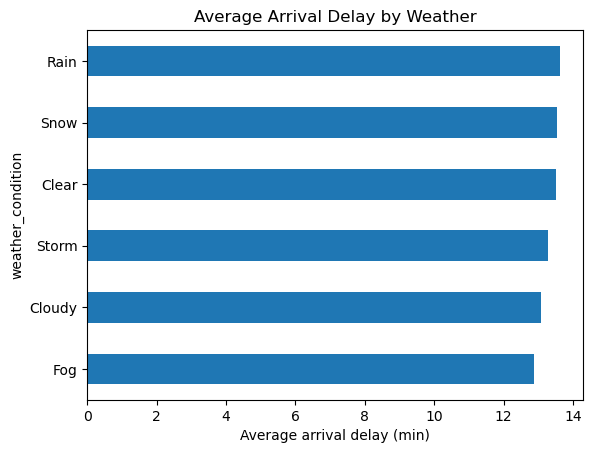

In [4]:
df.groupby('weather_condition')['actual_arrival_delay_min'].mean().sort_values().plot(kind='barh')
plt.xlabel('Average arrival delay (min)')
plt.title('Average Arrival Delay by Weather')
plt.show()

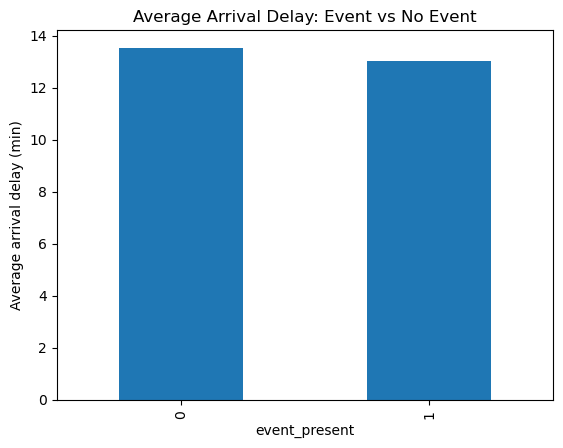

In [5]:
df.assign(event_present=(df['event_type'] != 'NoEvent').astype(int)) \
  .groupby('event_present')['actual_arrival_delay_min'].mean() \
  .plot(kind='bar')
plt.ylabel('Average arrival delay (min)')
plt.title('Average Arrival Delay: Event vs No Event')
plt.show()

In [10]:
import pandas as pd
import numpy as np

df_fe = df.copy()

# Fill missing event values
if "event_type" in df_fe.columns:
    df_fe["event_type"] = df_fe["event_type"].fillna("NoEvent").replace("", "NoEvent")
else:
    df_fe["event_type"] = "NoEvent"

# Date features
df_fe["date"] = pd.to_datetime(df_fe["date"], errors="coerce")
df_fe["month"] = df_fe["date"].dt.month
df_fe["day"] = df_fe["date"].dt.day
df_fe["day_of_year"] = df_fe["date"].dt.dayofyear
df_fe["is_weekend"] = (df_fe["date"].dt.dayofweek >= 5).astype(int)

# Time parsing
dep_split = df_fe["scheduled_departure"].astype(str).str.split(":", expand=True)
arr_split = df_fe["scheduled_arrival"].astype(str).str.split(":", expand=True)

df_fe["scheduled_departure_hour"] = pd.to_numeric(dep_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_departure_minute"] = pd.to_numeric(dep_split[1], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_hour"] = pd.to_numeric(arr_split[0], errors="coerce").fillna(0).astype(int)
df_fe["scheduled_arrival_minute"] = pd.to_numeric(arr_split[1], errors="coerce").fillna(0).astype(int)

df_fe["scheduled_departure_minute_of_day"] = (
    df_fe["scheduled_departure_hour"] * 60 + df_fe["scheduled_departure_minute"]
)
df_fe["scheduled_arrival_minute_of_day"] = (
    df_fe["scheduled_arrival_hour"] * 60 + df_fe["scheduled_arrival_minute"]
)
df_fe["scheduled_trip_duration_min"] = (
    df_fe["scheduled_arrival_minute_of_day"] - df_fe["scheduled_departure_minute_of_day"]
).clip(lower=0)

# Peak hour flags
df_fe["is_morning_peak"] = df_fe["scheduled_departure_hour"].between(7, 10).astype(int)
df_fe["is_evening_peak"] = df_fe["scheduled_departure_hour"].between(16, 19).astype(int)
df_fe["is_commute_peak"] = ((df_fe["is_morning_peak"] == 1) | (df_fe["is_evening_peak"] == 1)).astype(int)

# Event features
df_fe["has_event"] = (df_fe["event_type"].astype(str).str.lower() != "noevent").astype(int)

# Find event attendance column safely
possible_event_size_cols = ["event_attendance", "event_size", "attendance"]
event_size_col = None
for col in possible_event_size_cols:
    if col in df_fe.columns:
        event_size_col = col
        break

if event_size_col is not None:
    event_size = pd.to_numeric(df_fe[event_size_col], errors="coerce").fillna(0)
else:
    event_size = pd.Series([0] * len(df_fe), index=df_fe.index)

df_fe["event_size_bucket"] = pd.cut(
    event_size,
    bins=[-1, 0, 1000, 10000, float("inf")],
    labels=["NoEvent", "Small", "Medium", "Large"]
).astype(str)

# Weather features
weather_text = df_fe["weather_condition"].astype(str).str.lower()
df_fe["is_rain"] = weather_text.str.contains("rain", na=False).astype(int)
df_fe["is_snow"] = weather_text.str.contains("snow", na=False).astype(int)
df_fe["is_storm"] = weather_text.str.contains("storm|thunder", na=False).astype(int)
df_fe["is_fog"] = weather_text.str.contains("fog|mist|haze", na=False).astype(int)
df_fe["is_bad_weather"] = (
    (df_fe["is_rain"] == 1) |
    (df_fe["is_snow"] == 1) |
    (df_fe["is_storm"] == 1) |
    (df_fe["is_fog"] == 1)
).astype(int)

# Numeric threshold-based flags
df_fe["is_heavy_precip"] = (pd.to_numeric(df_fe["precipitation_mm"], errors="coerce").fillna(0) >= 5).astype(int)
df_fe["is_high_wind"] = (pd.to_numeric(df_fe["wind_speed_kmh"], errors="coerce").fillna(0) >= 25).astype(int)
df_fe["is_high_humidity"] = (pd.to_numeric(df_fe["humidity_%"], errors="coerce").fillna(0) >= 80).astype(int)
df_fe["is_extreme_temp"] = (
    (pd.to_numeric(df_fe["temperature_C"], errors="coerce").fillna(0) <= 0) |
    (pd.to_numeric(df_fe["temperature_C"], errors="coerce").fillna(0) >= 35)
).astype(int)
df_fe["is_high_congestion"] = (pd.to_numeric(df_fe["traffic_congestion_level"], errors="coerce").fillna(0) >= 7).astype(int)

print("Feature engineered dataframe shape:", df_fe.shape)
print("\nCreated columns:")
print([
    "month", "day", "day_of_year", "is_weekend",
    "scheduled_departure_hour", "scheduled_arrival_hour",
    "scheduled_trip_duration_min", "has_event", "event_size_bucket",
    "is_rain", "is_snow", "is_bad_weather", "is_high_congestion"
])

df_fe.head()

KeyError: 'humidity_%'